# Quantity Analysis - Time Series

## Objective
Analyze and forecast **quantity trends** over time using time series analysis techniques.

## Dataset Overview
The dataset contains timestamped records of quantities sold or produced.

## Workflow
1. Load the data
2. Explore time-based patterns
3. Resample and smooth
4. Train a forecasting model
5. Visualize predictions

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load data from Excel file
df = pd.read_excel('Raw Data_Predictive Analysis.xlsx') 
df.head()


,OrderDate,ParentProductIdNew,ParentProductNew,ProductCategoryNew,ArtistNameNew,total_qty_sales,Selling Price,productListViews,productListClicks
0,2019-01-01,11,Product 11,Category 1,TSSOS,3,399.0,NaN,NaN
1,2019-01-01,114,Product 114,Category 8,TSSA,10,549.0,NaN,NaN
2,2019-01-01,98,Product 98,Category 8,TSSHT,8,499.0,NaN,NaN
3,2019-01-01,97,Product 97,Category 8,TSSF,6,549.0,NaN,NaN
4,2019-01-01,8,Product 8,Category 1,TSSML,6,399.0,NaN,NaN


## Exploratory Data Analysis

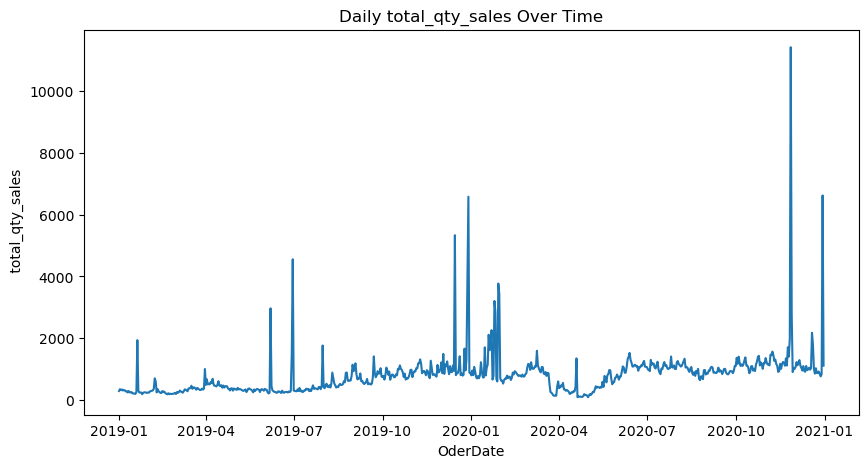

In [3]:
# Convert to datetime if necessary
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Remove invalid dates if any
df = df.dropna(subset=['OrderDate'])

# Sort values
df = df.sort_values('OrderDate')

# Group and directly create time series with Date as index
time_series = (
    df.groupby('OrderDate')['total_qty_sales']
      .sum()
      .sort_index()
)

# Display first rows
time_series.head()

# Plot raw time series
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(time_series)
plt.title("Daily total_qty_sales Over Time")
plt.xlabel("OderDate")
plt.ylabel(" total_qty_sales")
plt.show()

## Decomposition

In [29]:
# Set date as index
# Convert first column to datetime
df.iloc[:,0] = pd.to_datetime(df.iloc[:,0], errors='coerce')

# Drop invalid dates
df = df.dropna()

# Set first column as index
df.set_index(df.columns[0], inplace=True)

df.head()

# Create time series (assuming Quantity column)
time_series = df['total_qty_sales']

time_series.head()

ParentProductIdNew
1970-01-01 00:00:00.000000072     1
1970-01-01 00:00:00.000000106     7
1970-01-01 00:00:00.000000096    41
1970-01-01 00:00:00.000000099    24
1970-01-01 00:00:00.000000109    40
Name: total_qty_sales, dtype: int64

## Modeling with ARIMA

In [27]:
# Train-test split
train_size = int(len(time_series) * 0.8)

train = time_series[:train_size]
test = time_series[train_size:]

print("Train size:", train.shape)
print("Test size:", test.shape)

# Fit ARIMA model
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()
print(model_fit.summary())

# Forecast
rolling_value = train.rolling(window=7).mean().iloc[-1]

forecast = pd.DataFrame(test)
forecast['Predicted'] = rolling_value

Train size: (584,)
Test size: (147,)
                               SARIMAX Results                                
Dep. Variable:        total_qty_sales   No. Observations:                  584
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -4405.998
Date:                Mon, 09 Mar 2026   AIC                           8821.996
Time:                        20:11:59   BIC                           8843.837
Sample:                    01-01-2019   HQIC                          8830.510
                         - 08-06-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0878      0.269      0.326      0.744      -0.439       0.615
ar.L2         -0.0777      0.096     -0.810      0.418      -0.266       0.110
ma.L1         -

## Evaluation and Visualization

RMSE: 0.0
MAE: 0.0


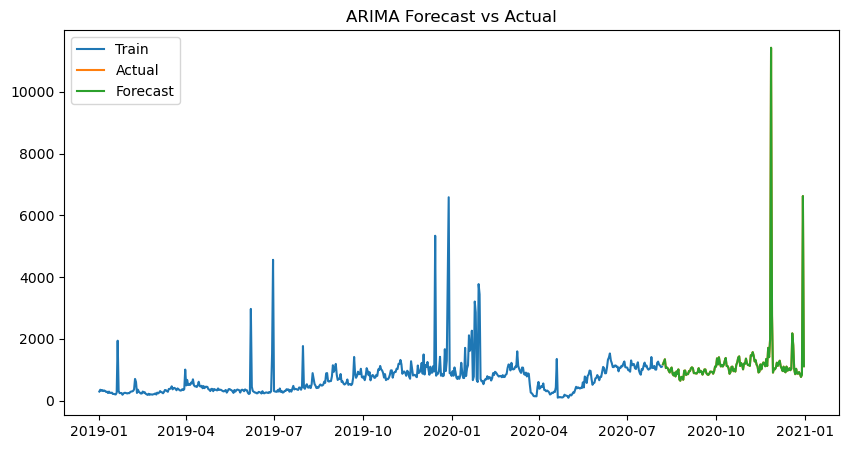

In [25]:
# Evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error as mae
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
mae_value = mae(test, forecast)

print("RMSE:", rmse)
print("MAE:", mae_value)

# Plot forecast vs actual
plt.figure(figsize=(10,5))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

## Conclusion
- Time series modeling was applied to understand and forecast quantity trends.
- ARIMA provided a simple baseline.
- For improvement, consider SARIMA, Prophet, or LSTM for long-term patterns.